Размер: (225, 225)


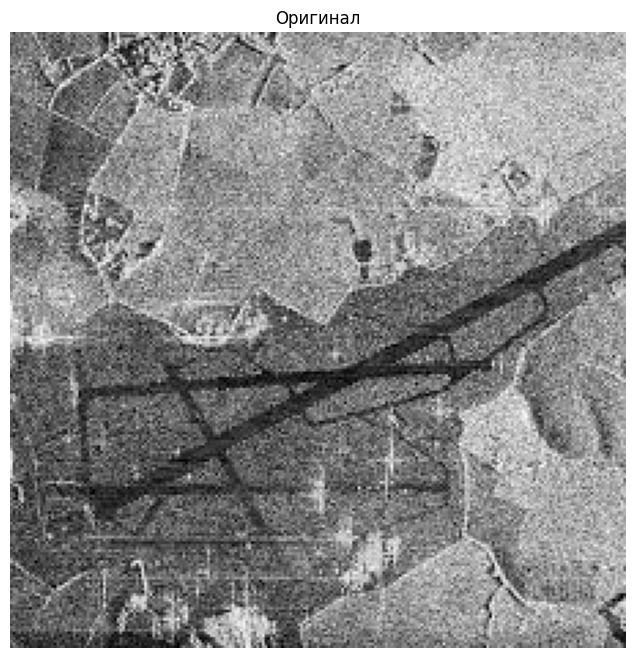

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Размер:", image_gray.shape)

plt.figure(figsize=(10, 8))
plt.imshow(image_gray, cmap='gray')
plt.title("Оригинал")
plt.axis('off')
plt.show()

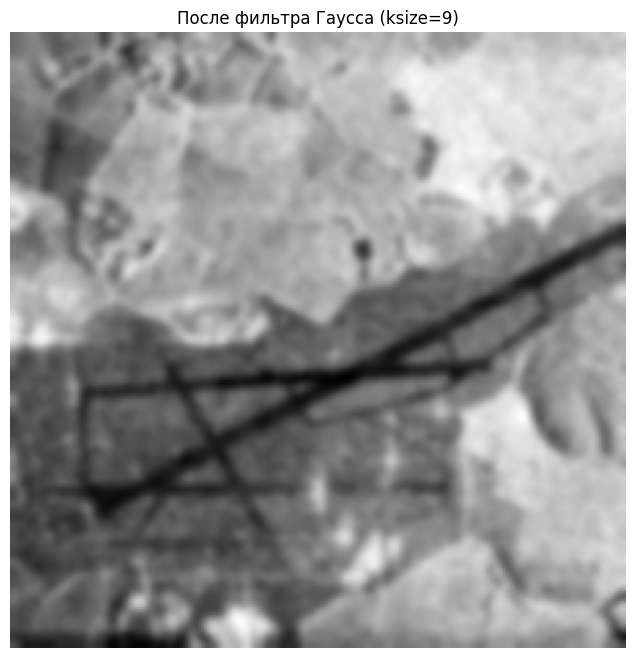

In [51]:
# гауссов фильтр
img = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


blur = cv2.GaussianBlur(gray, (9, 9), 0)

plt.figure(figsize=(10, 8))
plt.imshow(blur, cmap='gray')
plt.title("После фильтра Гаусса (ksize=9)")
plt.axis('off')
plt.show()

Длина самой длинной линии: 218.76 пикселей


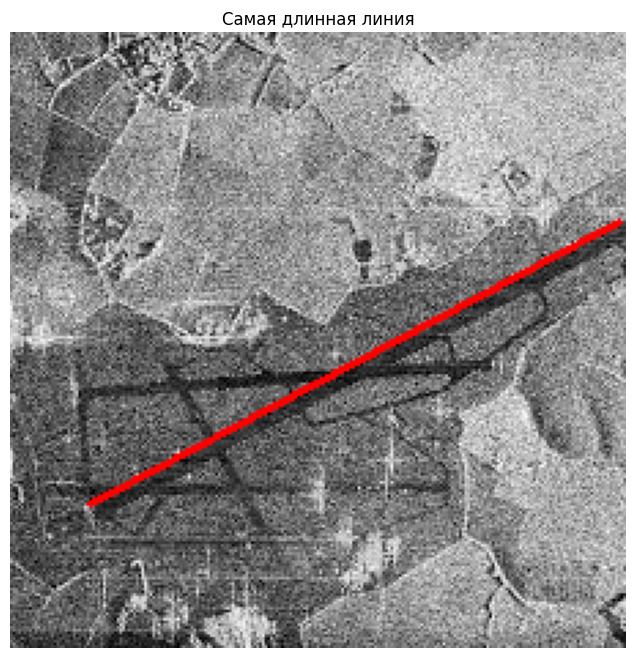

In [52]:
# canny
edges = cv2.Canny(blur, 50, 150)

# HoughLinesP
lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=80,
                        minLineLength=100,
                        maxLineGap=20)

# самый длинный
best = None
best_len = 0
if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = l[0]
        length = np.hypot(x2 - x1, y2 - y1)
        if length > best_len:
            best_len = length
            best = (x1, y1, x2, y2)


if best is not None:
    cv2.line(img, (best[0], best[1]), (best[2], best[3]), (0, 0, 255), 2)
    print("Длина самой длинной линии:", round(best_len, 2), "пикселей")

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Самая длинная линия")
plt.axis('off')
plt.show()

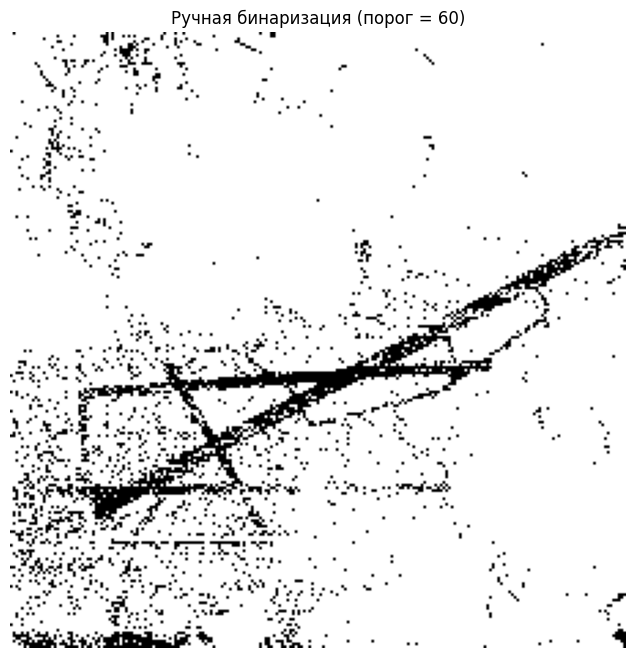

In [53]:
# ручная бинаризация

T = 60
bin_img = copy.deepcopy(image_gray)
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.figure(figsize=(10, 8))
plt.imshow(bin_img, cmap='gray')
plt.title(f"Ручная бинаризация (порог = {T})")
plt.axis('off')
plt.show()

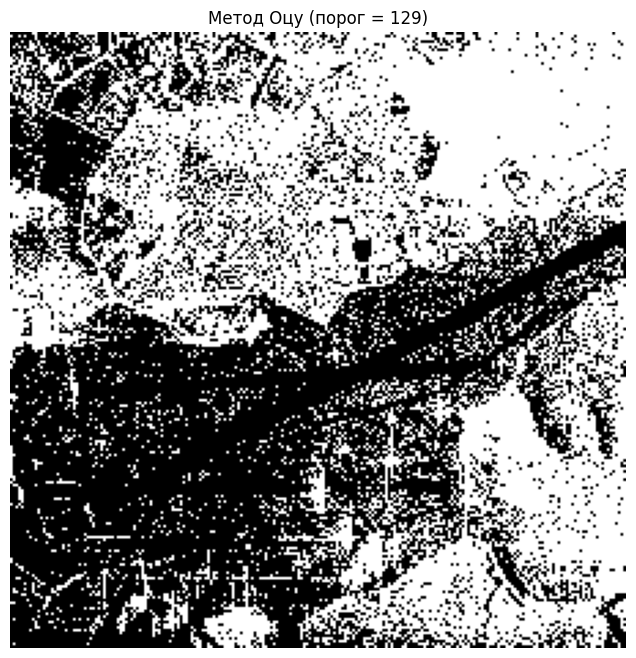

In [54]:
# метод оцу
ret, otsu_img = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10, 8))
plt.imshow(otsu_img, cmap='gray')
plt.title(f"Метод Оцу (порог = {round(ret)})")
plt.axis('off')
plt.show()

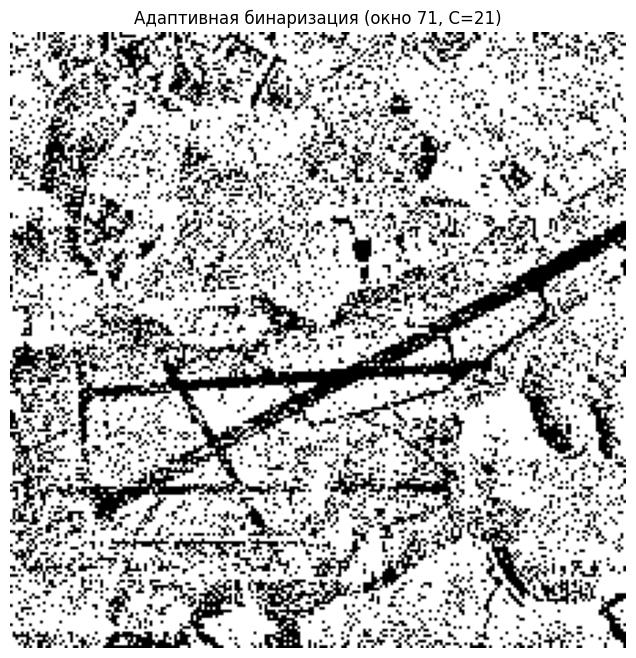

In [55]:
# адаптивная бинаризация
adaptive_img = cv2.adaptiveThreshold(image_gray, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 71, 21)

plt.figure(figsize=(10, 8))
plt.imshow(adaptive_img, cmap='gray')
plt.title("Адаптивная бинаризация (окно 71, C=21)")
plt.axis('off')
plt.show()